[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/thesis_apply/blob/main/notebooks/001-tests_y_primeras_validaciones.ipynb)

**Fecha:** 4 de marzo de 2026

<h1>1. Exploración inicial: inclinación orbital & dinamica debido a momentum angular </h1>

# Verificación del resultado teórico: Rango de la inclinación orbital periodico.

In [1]:
!pip install -Uq relatipy==0.2.1 

In [2]:
import relatipy.numeric as rn
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import find_peaks
import pandas as pd
from relatipy.visualization._2D import SciSubplot

## Orbita estable

In [3]:
kerr_metric = rn.metrics.Kerr(
    mass=1,
    a=0.5,
)
R_s = kerr_metric.R_s

In [4]:
x1 = 4*R_s

ic = rn.coordinates.Spherical(
    xs=[0, x1, np.pi/3, 0],
    vels=[0, 0, np.sqrt(1/x1)],
)

In [5]:
P = 2*np.pi*np.sqrt(x1**3)
times = np.linspace(0, 50*P, 2000)
path = kerr_metric.geodesic.get_path(ic, times)

/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/ldiaz/Documents/Documentos/otros/thesis_apply/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [6]:
from relatipy.visualization._3D import construct_basic_path_plot

fig = construct_basic_path_plot(R_s, path)
fig.show()

In [7]:
path_oe = path.convert_to("OrbitalElements", mass=1)

FileNotFoundError: [Errno 2] No such file or directory: '../figures/tests_y_primeras_validaciones/inclination_orbital_schwarzschild.png'

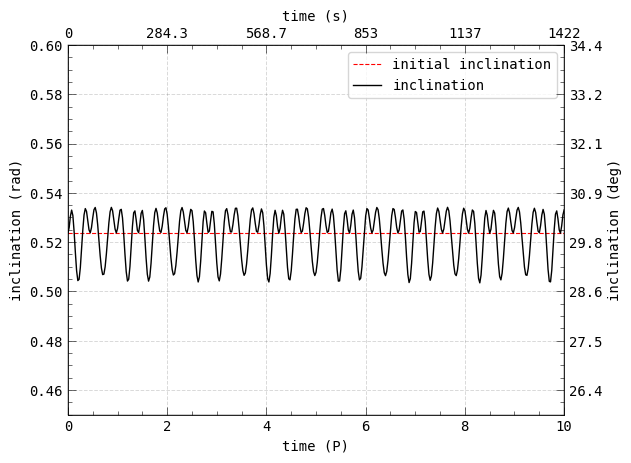

In [8]:

workspace = SciSubplot()
workspace.add_second_scale_horizontal(lambda x: x*P, "time (s)")
workspace.add_second_scale_vertical(lambda x: np.round(x*180/np.pi,1), "inclination (deg)")

fig, ax = workspace.fig, workspace.ax

ax.plot([0, 50], [np.pi/6, np.pi/6], "--r", label="initial inclination", linewidth=0.8)
ax.plot(times/P, path_oe.inc, '-k', label="inclination", linewidth=1)

ax.set_ylim(0.45, 0.6)
ax.set_xlim(0, 10)
ax.legend()

ax.set_xlabel("time (P)")
ax.set_ylabel("inclination (rad)")

fig.canvas.draw()
fig.savefig("../figures/tests_y_primeras_validaciones/inclination_orbital_schwarzschild.png", dpi=200)

plt.show()

  f (Hz)    T / P   ciclos  a_i (sin)  b_i (cos)      C_i
0.014904 0.471934 105.9470   0.006254   0.007243 0.009569
0.029808 0.235967 211.8940  -0.005596  -0.000695 0.005639
0.024746 0.284233 175.9120   0.000985   0.003018 0.003175
0.034729 0.202530 246.8765   0.001321  -0.002066 0.002452
0.019825 0.354787 140.9295  -0.001586   0.000693 0.001731
0.009842 0.714643  69.9650   0.000617  -0.001561 0.001679
0.005062 1.389584  35.9820  -0.000645  -0.000366 0.000742
0.039791 0.176767 282.8585  -0.000349  -0.000517 0.000624
0.049633 0.141714 352.8235  -0.000061  -0.000487 0.000491
0.044571 0.157808 316.8415   0.000347  -0.000293 0.000454
0.054695 0.128599 388.8055  -0.000146  -0.000046 0.000153


/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_75331/2057486406.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


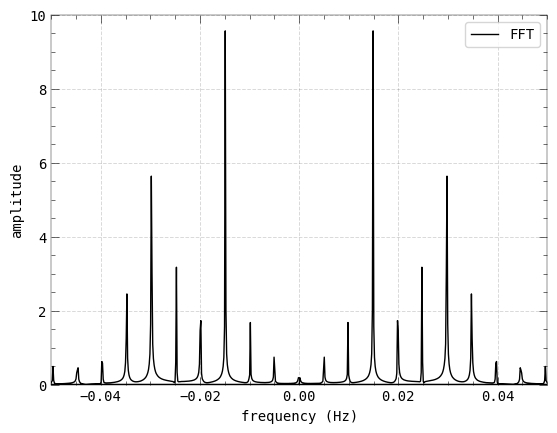

In [ ]:
inc_mean = np.mean(path_oe.inc)
signal = path_oe.inc - inc_mean
N = len(signal)
fft_inc = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, times[1]-times[0])

workspace = SciSubplot()
fig, ax = workspace.fig, workspace.ax

ax.plot(freqs, np.abs(fft_inc), '-k', label="FFT", lw=1)

ax.set_xlim(-0.05, 0.05)
ax.set_ylim(0, 10)
ax.legend()

ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("amplitude")

fig.canvas.draw()
fig.savefig("../figures/001-tests_y_primeras_validaciones/inclination_orbital_schwarzschild_fft.png", dpi=200)

fig.show()

mask = freqs > 0
freqs_pos = freqs[mask]
fft_pos   = fft_inc[mask]
power_pos = np.abs(fft_pos)

peaks_idx, _ = find_peaks(power_pos, prominence=np.max(power_pos)*0.01)
peak_freqs  = freqs_pos[peaks_idx]
peak_fft    = fft_pos[peaks_idx]
peak_amps   = power_pos[peaks_idx]

order = np.argsort(peak_amps)[::-1]
peak_freqs = peak_freqs[order]
peak_fft   = peak_fft[order]
peak_amps  = peak_amps[order]

peak_periods = 1 / peak_freqs
total_time   = times[-1] - times[0]

a_coeffs  = -2 * np.imag(peak_fft) / N
b_coeffs  =  2 * np.real(peak_fft) / N
amp_total = np.sqrt(a_coeffs**2 + b_coeffs**2)

df = pd.DataFrame({
    'f (Hz)':    peak_freqs,
    'T / P':     peak_periods / P,
    'ciclos':    total_time / peak_periods,
    'a_i (sin)': a_coeffs,
    'b_i (cos)': b_coeffs,
    'C_i':       amp_total,
})

print(df.to_string(index=False))

/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_75331/1131471372.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


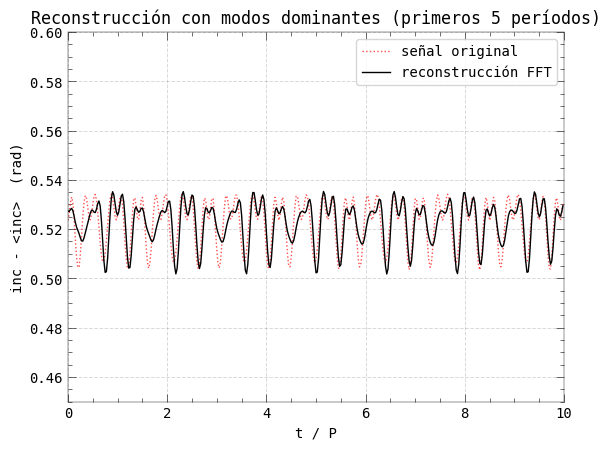

In [ ]:
t = times - times[0]
mask_t = t <= 10 * P

signal_reconstructed = np.zeros_like(t)
for a, b, f in zip(a_coeffs, b_coeffs, peak_freqs):
    nu = 2 * np.pi * f
    signal_reconstructed += a * np.sin(nu * t) + b * np.cos(nu * t)

workspace = SciSubplot()
ax = workspace.ax
fig = workspace.fig

ax.plot(t[mask_t] / P, signal[mask_t] + inc_mean, ":r", label='señal original', alpha=0.7, lw=1)
ax.plot(t[mask_t] / P, signal_reconstructed[mask_t] + inc_mean, '-k', label='reconstrucción FFT', lw=1)


ax.set_xlabel("t / P")
ax.set_ylabel("inc - <inc>  (rad)")
ax.set_title("Reconstrucción con modos dominantes (primeros 5 períodos)")

ax.set_ylim(0.45, 0.6)
ax.set_xlim(0, 10)
ax.legend()

fig.canvas.draw()
fig.savefig("../figures/001-tests_y_primeras_validaciones/inclination_orbital_schwarzschild_reconstruction.png", dpi=200)

fig.show()

In [ ]:
max_inc = np.max(path_oe.inc)
min_inc = np.min(path_oe.inc)
print(f"initial inclination: {path_oe.inc[0]*180/np.pi}")
print(f"max inc: {max_inc*180/np.pi}, min inc: {min_inc*180/np.pi}")

initial inclination: 29.999999999999986
max inc: 30.60281785676256, min inc: 28.815223452521124


## Orbita inestable

In [ ]:
x1 = 4*R_s

ic = rn.coordinates.Spherical(
    xs=[0, x1, np.pi/3, 0],
    vels=[0, 0, np.sqrt(1/x1)*1.1],
)

In [ ]:
P = 2*np.pi*np.sqrt(x1**3)
times = np.linspace(0, 50*P, 2000)
path = kerr_metric.geodesic.get_path(ic, times)

In [ ]:
from relatipy.visualization._3D import construct_basic_path_plot
fig = construct_basic_path_plot(R_s, path)
fig.write_html("../figures/001-tests_y_primeras_validaciones/path_3d_unstable.html")

fig.show()

In [ ]:
path_oe = path.convert_to("OrbitalElements", mass=1)

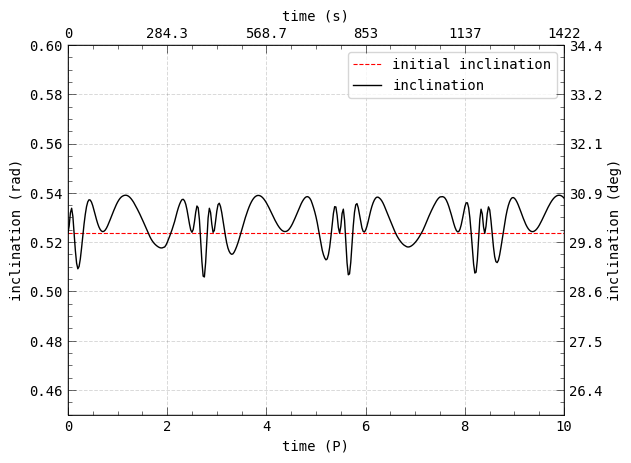

In [ ]:

workspace = SciSubplot()
workspace.add_second_scale_horizontal(lambda x: x*P, "time (s)")
workspace.add_second_scale_vertical(lambda x: np.round(x*180/np.pi,1), "inclination (deg)")

fig, ax = workspace.fig, workspace.ax

ax.plot([0, 50], [np.pi/6, np.pi/6], "--r", label="initial inclination", linewidth=0.8)
ax.plot(times/P, path_oe.inc, '-k', label="inclination", linewidth=1)

ax.set_ylim(0.45, 0.6)
ax.set_xlim(0, 10)
ax.legend()

ax.set_xlabel("time (P)")
ax.set_ylabel("inclination (rad)")

fig.canvas.draw()
fig.savefig("../figures/tests_y_primeras_validaciones/inclination_orbital_schwarzschild_unstable.png", dpi=200)

plt.show()

  f (Hz)     T / P   ciclos  a_i (sin)  b_i (cos)      C_i
0.008155  0.862500  57.9710  -0.000060  -0.004666 0.004666
0.005624  1.250625  39.9800  -0.000264   0.004418 0.004426
0.004078  1.725000  28.9855  -0.000016  -0.003751 0.003751
0.002531  2.779167  17.9910  -0.000198  -0.002764 0.002771
0.015748  0.446652 111.9440   0.000525   0.002357 0.002415
0.011670  0.602711  82.9585   0.000514   0.002351 0.002407
0.014201  0.495297 100.9495   0.000635   0.002159 0.002251
0.009139  0.769616  64.9675   0.000266   0.001857 0.001876
0.016732  0.420378 118.9405   0.000644   0.001734 0.001850
0.010686  0.658224  75.9620  -0.000144  -0.001666 0.001672
0.013217  0.532181  93.9530   0.000243   0.001647 0.001665
0.018279  0.384808 129.9350   0.000439   0.001446 0.001511
0.028402  0.247649 201.8990  -0.000776  -0.001279 0.001496
0.030933  0.227386 219.8900  -0.000810  -0.001143 0.001401
0.019263  0.365146 136.9315   0.000577   0.001276 0.001401
0.025871  0.271875 183.9080  -0.000621  -0.001204 0.0013

/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_75331/3283174348.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


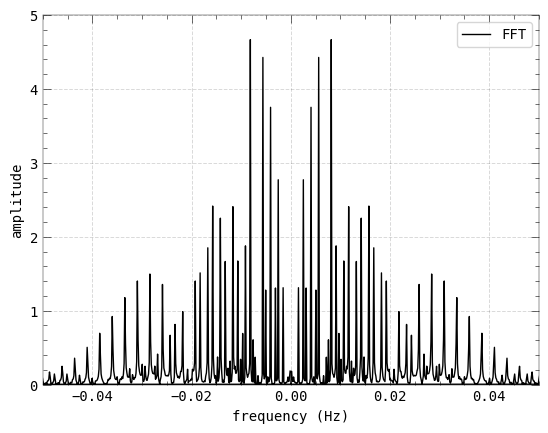

In [ ]:
inc_mean = np.mean(path_oe.inc)
signal = path_oe.inc - inc_mean
N = len(signal)
fft_inc = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, times[1]-times[0])

workspace = SciSubplot()
fig, ax = workspace.fig, workspace.ax

ax.plot(freqs, np.abs(fft_inc), '-k', label="FFT", lw=1)

ax.set_xlim(-0.05, 0.05)
ax.set_ylim(0, 5)
ax.legend()

ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("amplitude")

fig.canvas.draw()
fig.savefig("../figures/001-tests_y_primeras_validaciones/inclination_orbital_schwarzschild_fft_unstable.png", dpi=200)

fig.show()

mask = freqs > 0
freqs_pos = freqs[mask]
fft_pos   = fft_inc[mask]
power_pos = np.abs(fft_pos)

peaks_idx, _ = find_peaks(power_pos, prominence=np.max(power_pos)*0.01)
peak_freqs  = freqs_pos[peaks_idx]
peak_fft    = fft_pos[peaks_idx]
peak_amps   = power_pos[peaks_idx]

order = np.argsort(peak_amps)[::-1]
peak_freqs = peak_freqs[order]
peak_fft   = peak_fft[order]
peak_amps  = peak_amps[order]

peak_periods = 1 / peak_freqs
total_time   = times[-1] - times[0]

a_coeffs  = -2 * np.imag(peak_fft) / N
b_coeffs  =  2 * np.real(peak_fft) / N
amp_total = np.sqrt(a_coeffs**2 + b_coeffs**2)

df = pd.DataFrame({
    'f (Hz)':    peak_freqs,
    'T / P':     peak_periods / P,
    'ciclos':    total_time / peak_periods,
    'a_i (sin)': a_coeffs,
    'b_i (cos)': b_coeffs,
    'C_i':       amp_total,
})

print(df.to_string(index=False))

/var/folders/8g/jy3rvzr50kv5w6g24cxmq6kc0000gp/T/ipykernel_75331/7910004.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


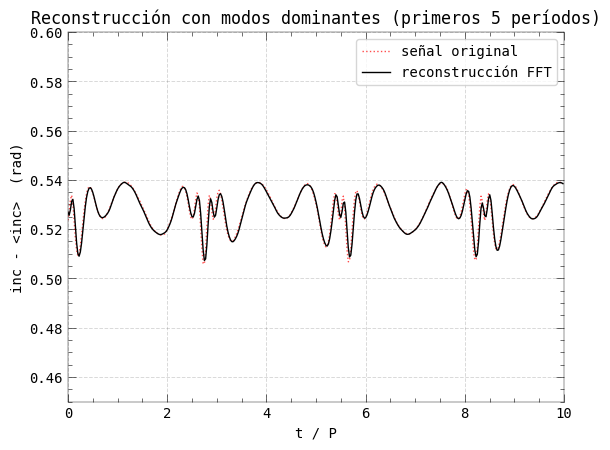

In [ ]:
t = times - times[0]
mask_t = t <= 10 * P

signal_reconstructed = np.zeros_like(t)
for a, b, f in zip(a_coeffs, b_coeffs, peak_freqs):
    nu = 2 * np.pi * f
    signal_reconstructed += a * np.sin(nu * t) + b * np.cos(nu * t)

workspace = SciSubplot()
ax = workspace.ax
fig = workspace.fig

ax.plot(t[mask_t] / P, signal[mask_t] + inc_mean, ":r", label='señal original', alpha=0.7, lw=1)
ax.plot(t[mask_t] / P, signal_reconstructed[mask_t] + inc_mean, '-k', label='reconstrucción FFT', lw=1)


ax.set_xlabel("t / P")
ax.set_ylabel("inc - <inc>  (rad)")
ax.set_title("Reconstrucción con modos dominantes (primeros 5 períodos)")

ax.set_ylim(0.45, 0.6)
ax.set_xlim(0, 10)
ax.legend()

fig.canvas.draw()
fig.savefig("../figures/001-tests_y_primeras_validaciones/inclination_orbital_schwarzschild_reconstruction_unstable.png", dpi=200)

fig.show()

In [ ]:
max_inc = np.max(path_oe.inc)
min_inc = np.min(path_oe.inc)
print(f"initial inclination: {path_oe.inc[0]*180/np.pi}")
print(f"max inc: {max_inc*180/np.pi}, min inc: {min_inc*180/np.pi}")

initial inclination: 29.999999999999986
max inc: 30.8865574330349, min inc: 28.920998467226283
